In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_csv("../data/crop_yield.csv")
df.head()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Andaman and Nicobar,7000,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Andaman and Nicobar,5000,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Andaman and Nicobar,7000,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Andaman and Nicobar,7000,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Andaman and Nicobar,120000,Rice


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (2200, 10)

Columns:
['N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'STATE', 'CROP_PRICE', 'CROP']

Missing Values:
N_SOIL         0
P_SOIL         0
K_SOIL         0
TEMPERATURE    0
HUMIDITY       0
ph             0
RAINFALL       0
STATE          0
CROP_PRICE     0
CROP           0
dtype: int64

Data Types:
N_SOIL           int64
P_SOIL           int64
K_SOIL           int64
TEMPERATURE    float64
HUMIDITY       float64
ph             float64
RAINFALL       float64
STATE              str
CROP_PRICE       int64
CROP               str
dtype: object


In [8]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2200, 10)


In [9]:
target = "CROP_PRICE"

X = df.drop(columns=[target])
y = df[target]

In [10]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['STATE', 'CROP']
Numerical Columns: ['N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']


C:\Users\Admin\AppData\Local\Temp\ipykernel_21028\2525320560.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [11]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [12]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    )
}

In [16]:
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    # Predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = mean_squared_error(y_test, test_pred) ** 0.5
    overfitting_gap = train_r2 - test_r2

    results[name] = {
        "Train R2": train_r2,
        "Test R2": test_r2,
        "MAE": mae,
        "RMSE": rmse,
        "Overfitting Gap": overfitting_gap,
        "Pipeline": pipeline
    }

    print(f"\n{name}")
    print("-" * 40)
    print("Train R2:", round(train_r2, 4))
    print("Test R2 :", round(test_r2, 4))
    print("MAE     :", round(mae, 2))
    print("RMSE    :", round(rmse, 2))
    print("Overfitting Gap:", round(overfitting_gap, 4))


Linear Regression
----------------------------------------
Train R2: 0.1976
Test R2 : 0.0029
MAE     : 1743.35
RMSE    : 2612.06
Overfitting Gap: 0.1946

Random Forest
----------------------------------------
Train R2: 0.8546
Test R2 : -0.0376
MAE     : 1807.78
RMSE    : 2664.58
Overfitting Gap: 0.8922

XGBoost
----------------------------------------
Train R2: 0.9086
Test R2 : -0.3184
MAE     : 1844.24
RMSE    : 3003.66
Overfitting Gap: 1.227


In [17]:
comparison = pd.DataFrame({
    name: {
        k: v for k, v in metrics.items() if k != "Pipeline"
    }
    for name, metrics in results.items()
}).T

comparison = comparison.sort_values("Test R2", ascending=False)
comparison

,Train R2,Test R2,MAE,RMSE,Overfitting Gap
Linear Regression,0.197554,0.002941,1743.354794,2612.063092,0.194613
Random Forest,0.854629,-0.037552,1807.783045,2664.576420,0.892182
XGBoost,0.908588,-0.318422,1844.240479,3003.657937,1.227010


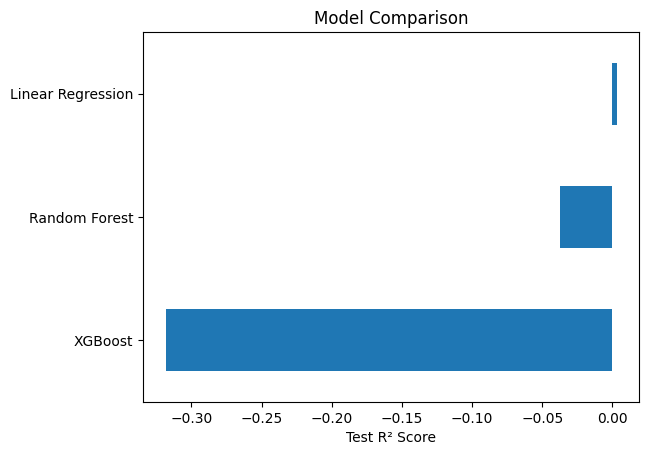

In [18]:
comparison["Test R2"].sort_values().plot(kind="barh")
plt.xlabel("Test R² Score")
plt.title("Model Comparison")
plt.show()

In [20]:
best_model_name = comparison.index[0]
best_pipeline = results[best_model_name]["Pipeline"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [21]:
joblib.dump(best_pipeline, "../models/best_model.pkl")
print("Model saved successfully!")

Model saved successfully!
